In [1]:
# Liberias fundamentales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética básica para los gráficos
sns.set_style('whitegrid')

# Cargar el dataset
df_california = pd.read_csv('housing.csv')

# 1. Mostrar las primeras 5 filas para entender la estructura visualmente
print("--- Primeras filas del dataset ---")
display(df_california.head())

# 2. Información básica: tipos de datos y conteo de valores no nulos
print("\n--- Información del Dataset ---")
df_california.info()

# 3. Estadísticas descriptivas: media, desviación estándar, mínimos y máximos
print("\n--- Estadísticas Descriptivas Básicas---")
display(df_california.describe())

--- Primeras filas del dataset ---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB

--- Estadísticas Descriptivas Básicas---


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# Limpieza y preprocesamiento base

In [2]:
# 1. Manejo de valores nulos: Identificar y contar los valores nulos en cada columna
print("\n--- Conteo de Valores Nulos por Columna ---")
print(df_california.isnull().sum())


--- Conteo de Valores Nulos por Columna ---
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [3]:
# 1. Manejo de valores nulos
# Calculamos la mediana de los dormitorios
mediana_dormitorios = df_california['total_bedrooms'].median()

# Rellenamos (imputamos) los valores nulos con esa mediana
df_california.fillna({'total_bedrooms': mediana_dormitorios}, inplace=True)

# Verificamos que ya no haya nulos
print("Valores nulos después de la limpieza:")
print(df_california.isnull().sum())

# 2. Análisis de la variable categórica (texto)
print("\n--- Categorías en 'ocean_proximity' ---")
display(df_california['ocean_proximity'].value_counts())

Valores nulos después de la limpieza:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

--- Categorías en 'ocean_proximity' ---


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

# Análisis Exploratorio Inicial (Distribuciones individuales)

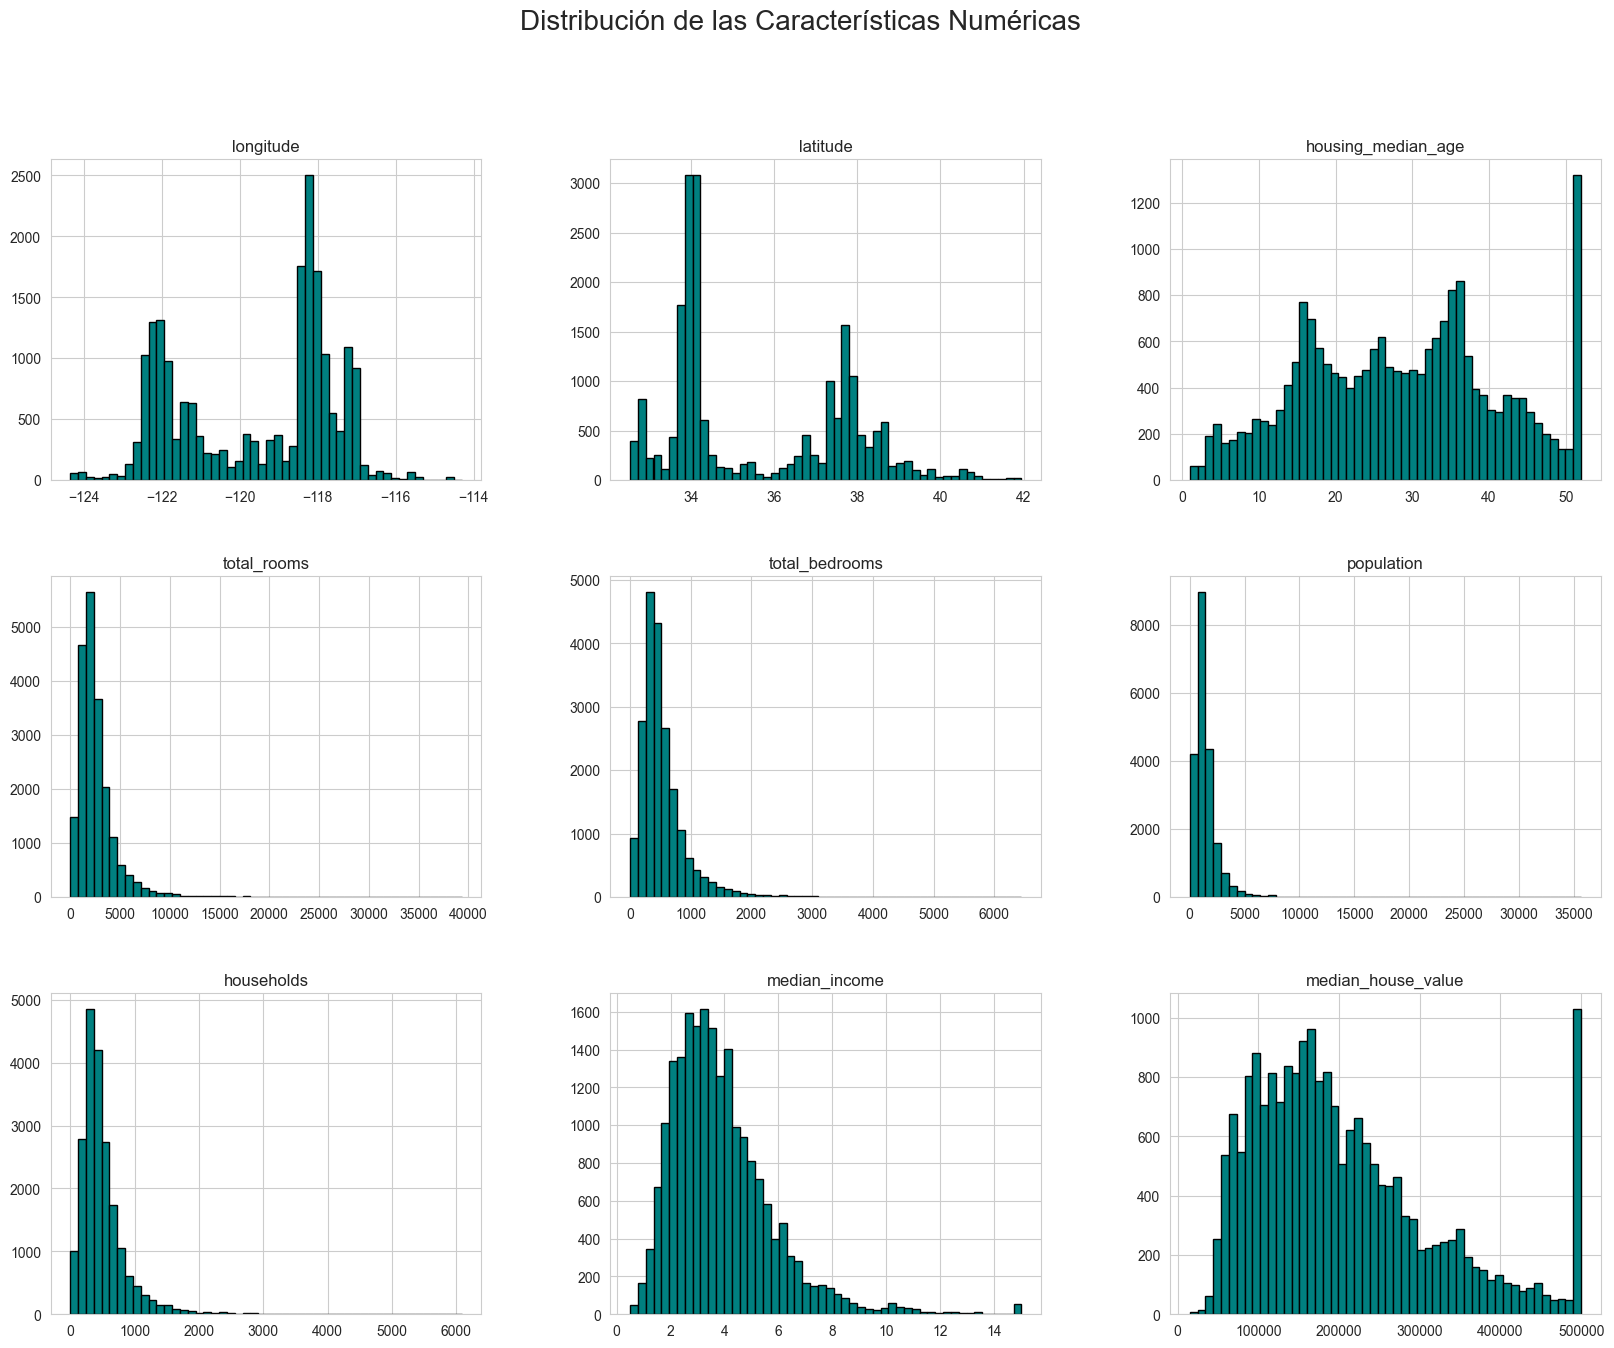

In [4]:
# Mapear la distribución de todas las variables numéricas
# bins=50 define la cantidad de "barras" o cajones en los gráficos
# figsize ajusta el tamaño total de la imagen para que sea vea bien en la pantalla
df_california.hist(bins=50, figsize=(20,15), color='teal', edgecolor='black')

# Añade un título general
plt.suptitle("Distribución de las Características Numéricas", fontsize=20)

# Mostrar los gráficos
plt.show()

### Conclusiones del Análisis de Distribuciones

Al observar los histogramas de las variables numéricas, podemos identificar tres fenómenos clave en los datos que debemos tener en cuenta para futuros modelos:

1. **Topes Artificiales (Capping):** La variable `median_house_value` muestra un pico atípico y masivo al final de su distribución (alrededor de los $500,000). Esto indica que los datos fueron limitados artificialmente durante su recolección; cualquier valor superior a ese umbral fue registrado con ese valor máximo. Ocurre un fenómeno idéntico en `housing_median_age` alrededor de los 50 años.
2. **Sesgo Positivo (Right-Skewness):** Variables como `median_income`, `total_rooms` y `population` tienen una "cola pesada" que se extiende hacia la derecha. Esto significa que la mayoría de los vecindarios tienen valores bajos o medios, pero existen unos pocos vecindarios con valores extremadamente altos (outliers) que estiran la distribución. 
3. **Escalas Diferentes:** Las variables están medidas en escalas muy distintas (ej. ingresos en decenas de miles vs. población en miles de personas). Si aplicamos algoritmos de Machine Learning más adelante, será crucial estandarizar o escalar estos datos.

# EDA AVANZADO (Segmentación y Filtrado)

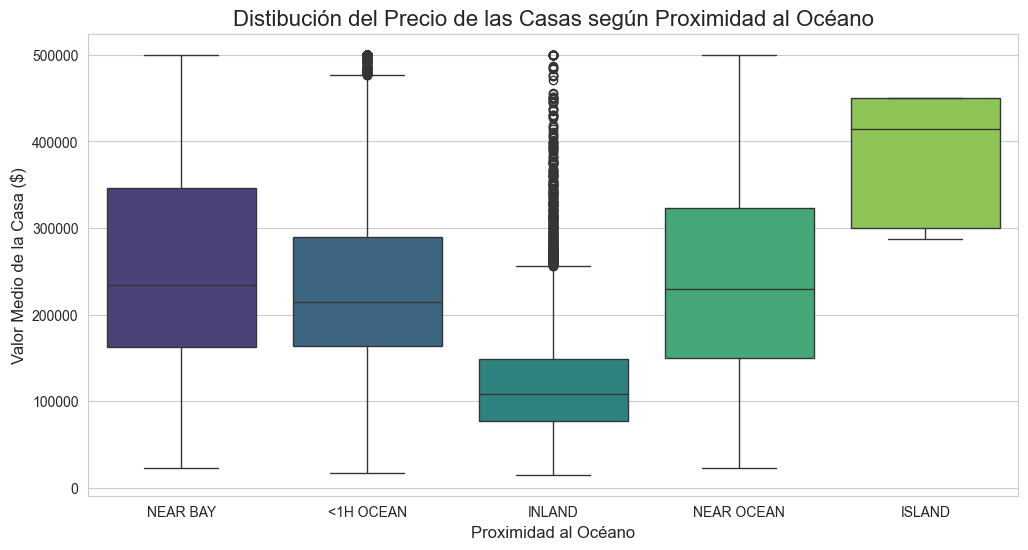

In [5]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Creación del boxplot
# x: nuestra categoría de texto, y: el precio que queremos analizar
sns.boxplot(
    data=df_california,
    x='ocean_proximity',
    y='median_house_value',
    hue='ocean_proximity', # Asignamos colores por categoría
    palette='viridis',
    legend=False
)

# Títulos y etiquetas para entender sin contexto
plt.title('Distibución del Precio de las Casas según Proximidad al Océano', fontsize=16)
plt.xlabel('Proximidad al Océano', fontsize=12)
plt.ylabel('Valor Medio de la Casa ($)', fontsize=12)

# Mostrar el gráfico
plt.show()

### Conclusiones del gráfico - Boxplot
- La linea central de la caja es la mediana (el valor del medio). Esto indica visualmente que categoría es, en general, la más cara.
- El tamaño de la caja representa el 50% central de los datos. Las cajas estiradas significan que los precios en esa zona varían mucho. Si es muy aplastada significa que los precios son similares entre sí.
- Los puntos fuera de las líneas: Estos son los Outliers, (valores atípicos)

# Relaciones y Correlaciones

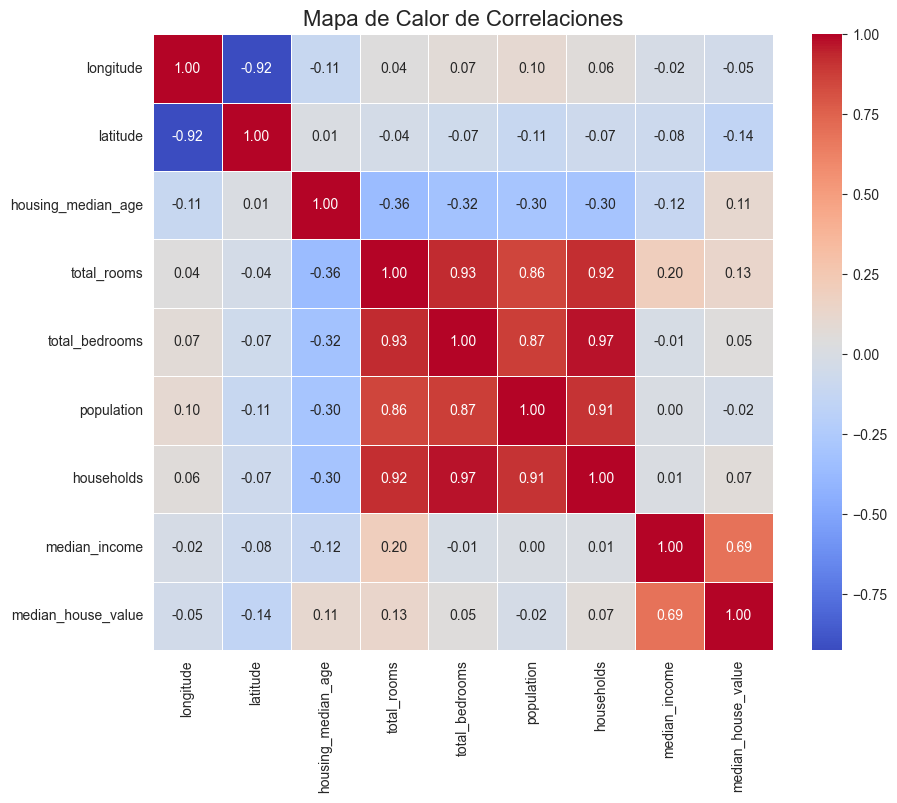


Generando Pairplot... (esto puede tomar unos segundos)


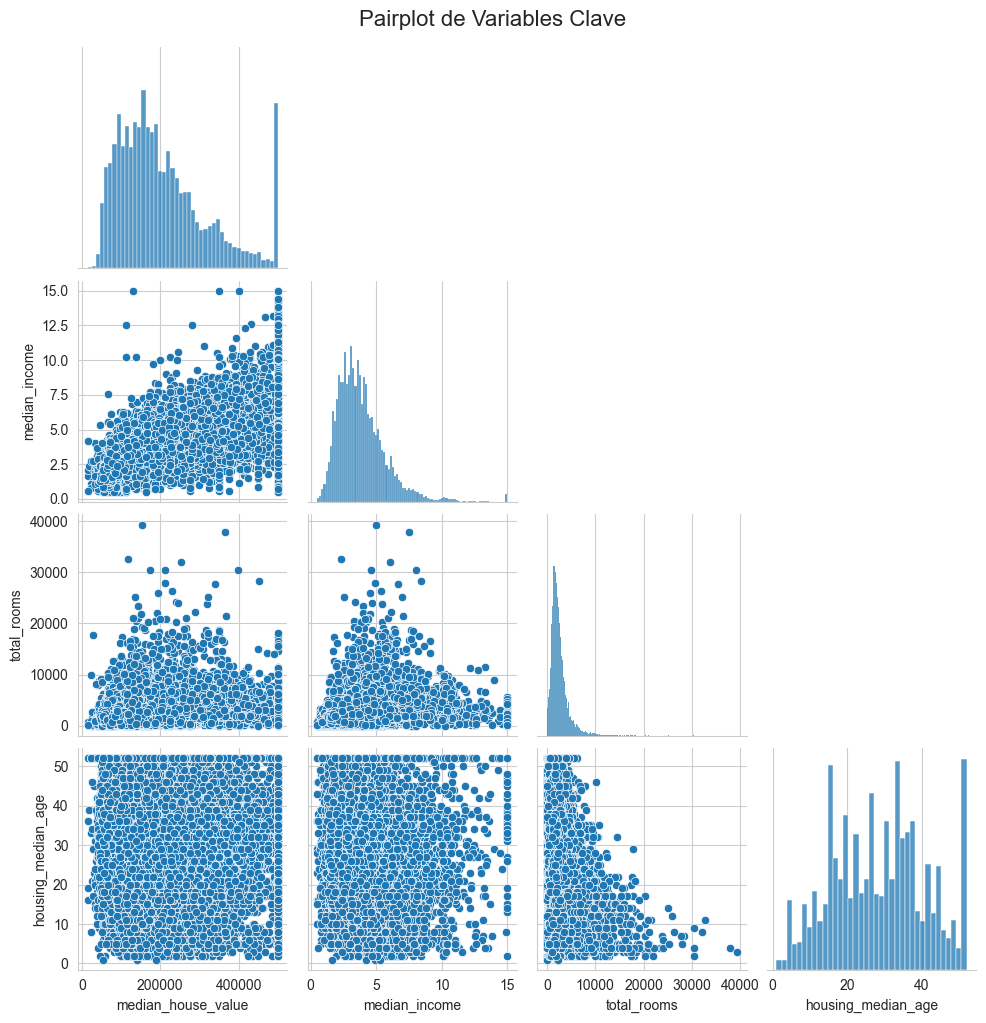

In [ ]:
# 1. PREPARACIÓN PARA EL HEATMAP
# Primero, seleccionamos solo las columnas numéricas (la correlación no funciona con textos)
columnas_numericas = df_california.select_dtypes(include=[np.number])

# Calculamos la matriz de correlación
matriz_correlacion = columnas_numericas.corr()

# 2. DIBUJAR EL HEATMAP
plt.figure(figsize=(10,8))
# annot=True pone los números dentro de los cuadritos, cmap es la paleta de colores
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones', fontsize=16)
plt.show()

# 3. DIBUJAR EL PAIRPLOT (Matriz de dispersión)
# Seleccionamos solo las variables que más nos interesan para no sobrecargar el gráfico
variables_clave = ['median_house_value', 'median_income', 'total_rooms', 'housing_median_age']

print("\nGenerando Pairplot... (esto puede tomar unos segundos)")
sns.pairplot(df_california[variables_clave], height=2.5, corner=True)
plt.suptitle('Pairplot de Variables Clave', y=1.02, fontsize=16)
plt.show()

### Conclusiones del Análisis de Correlación

Tras analizar el Mapa de Calor (Heatmap) y el Pairplot, extraemos los siguientes hallazgos:

1. **El factor Principal: Los ingresos (Median Income):** Existe una correlacion positiva fuerte (cercana a **0.69**) entre los ingresos medios de un vecindario y el valor medio de las casas. A medida que los ingresos suben, el precio de la propiedad se dispara. Esta es la relación lineal más clara de todo el dataset.
2. **Confirmación visual del Tope Artificial:** Al observar el gráfico de dispersión (scatter plot) entre `median_income` y `median_house_value` dentro del Pairplot, se hace muy evidente una línea horizontal sólida y antinatural exactamente en los **$500,000**. Esto reconfirma nuestra teoría anterior de que los datos fueron "topados" (capped) en ese valor límite durante la recolección del censo.
3. **Relaciones débiles en la estructura:** Variables como `total_rooms` o `housing_median_age` tienen una correlación sorprendentemente baja con el precio final de la casa en su estado puro. Esto nos da una pista de que el valor inmobiliario aquí depende mucho más de "quién vive ahí" (ingresos) y "dónde está" (como vimos con el océano), que de la antigüedad de la estructura misma.

### Visualización geográfica (Storytelling)

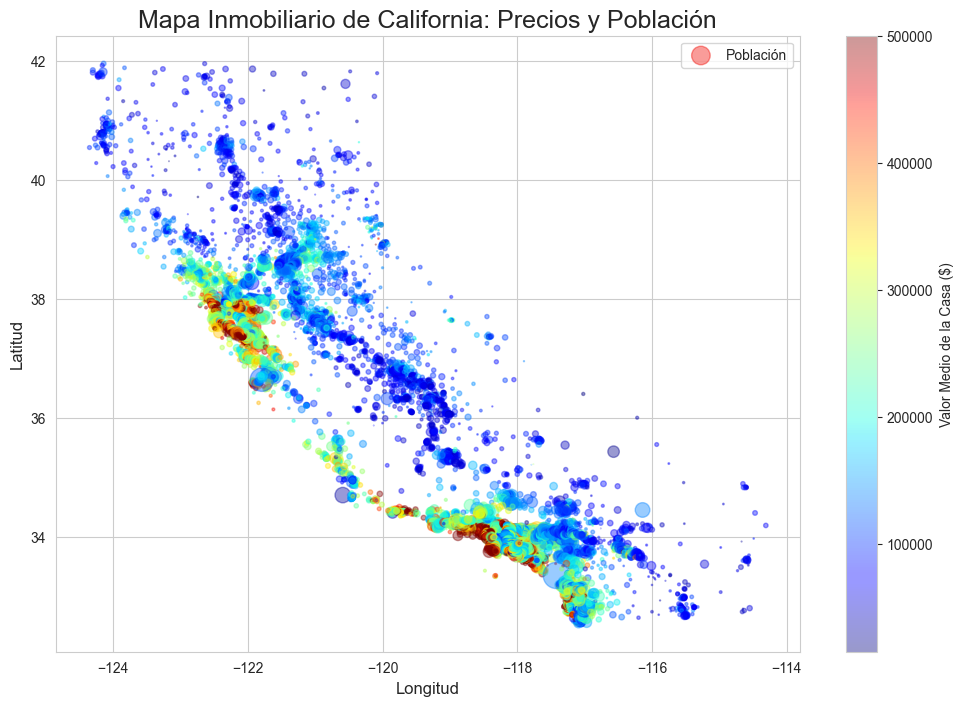

In [ ]:
# Configuración de lienzo para que sea grande y claro
from matplotlib.font_manager import font_scalings
plt.figure(figsize=(12,8))

# Creamos el gráfico de dispersión (scatter plot)
# x = longitud, y = latitud dibujarán la forma de la costa oeste

scatter = plt.scatter(
    x=df_california['longitude'],
    y=df_california['latitude'],
    alpha=0.4,                              # alpha da transparencia para ver donde hay mucha densidad
    s=df_california['population'] / 100,    # size: el tamaño depende de la población (se divide por 100 para que los circulos no sean gigantes)
    label='Población',
    c=df_california['median_house_value'],  # color: depende del precio de la casa
    cmap='jet'                              # mapa de colores (azul=barato, rojo=caro)
)

# Añadimos la barra de colores a la derecha para saber qué significa cada color
plt.colorbar(scatter, label='Valor Medio de la Casa ($)')

# Etiquetas y título
plt.title('Mapa Inmobiliario de California: Precios y Población', fontsize=18) 
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend()

# Mostrar el gráfico
plt.show()

### Conclusión: El Enigma de los Precios en California

Tras realizar la limpieza, el Análisis Exploratorio y la Visualización Geográfica, podemos responder al desafío inicial: **¿Qué hace que las casas sean tan caras en California?**

La respuesta se reduce a una combinación de dos factores principales:

1. **Ubicación, (La costa manda):** El mapa de calor geográfico demuestra visualmente que los precios más altos (en rojo) se concentran fuertemente en la costa del Océano Pacífico, específicamente formando clústeres alrededor de los grandes polos urbanos (Área de la Bahía y Los Ángeles). A medida que nos alejamos del océano hacia el interior (Inland), los precios caen drásticamente.
2. **Poder Adquisitivo (El factor Ingresos):** Como descubrimos en nuestro análisis de correlación (0.69), la cercanía al mar no lo es todo; el precio de las casas está íntimamente ligado a los ingresos medios de los residentes del vecindario. La demanda por vivir en estas zonas costeras privilegiadas atrae a personas con altos ingresos, lo que a su vez dispara el valor del mercado inmobiliario local.

*Nota técnica: Nuestro modelo futuro deberá tener cuidado con los topes artificiales (capping) en los $500,000 dólares detectados durante el EDA, ya que podrían sesgar las predicciones.*